# Relationship Score Prediction - Model Training

## Purpose
This notebook trains multiple machine learning models to predict relationship strength (0-100) between company and customers:
- Linear Regression
- Random Forest Regressor
- XGBoost Regressor
- Gradient Boosting Regressor
- Support Vector Regressor (SVR)
- **Ensemble Models:**
  - Voting Regressor
  - Stacking Regressor

## Workflow
1. Data Loading & Feature Engineering
2. Hyperparameter Tuning (Optional)
3. Model Training
4. Cross-Validation
5. Ensemble Models
6. Model Evaluation & Comparison
7. Overfitting Analysis
8. Save All Models

**All trained models are automatically saved to the `models/` directory.**

In [1]:
# Install required packages
!uv add scikit-learn xgboost matplotlib seaborn pandas numpy openpyxl joblib

Resolved 54 packages in 1ms
Audited 47 packages in 3ms


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
from datetime import datetime
import os

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    VotingRegressor, StackingRegressor
)
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    explained_variance_score, mean_absolute_percentage_error
)
import xgboost as xgb

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Data and Feature Engineering

In [3]:
# Load the dataset
possible_paths = [
    Path("../../customer_data_25000.xlsx"),
    Path("../customer_data_25000.xlsx"),
    Path("customer_data_25000.xlsx"),
    Path("D:/Internship/Renewal-Upsell-Advisor/Research/customer_data_25000.xlsx")
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find customer_data_25000.xlsx. Please check the file path.")

df = pd.read_excel(data_path, sheet_name="Accounts")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 24,874 rows × 27 columns


In [4]:
# Replicate feature engineering from EDA
df_rel = df.copy()

# Convert date columns to datetime
date_columns = ['contract_start_date', 'contract_end_date', 'renewal_date', 'last_contact_date']
for col in date_columns:
    if col in df_rel.columns:
        df_rel[col] = pd.to_datetime(df_rel[col], errors='coerce')

# Calculate days since last contact
if 'last_contact_date' in df_rel.columns:
    today = pd.Timestamp.now()
    df_rel['days_since_last_contact'] = (today - df_rel['last_contact_date']).dt.days

# Calculate contract duration in months
if 'contract_start_date' in df_rel.columns and 'contract_end_date' in df_rel.columns:
    if 'contract_duration_months' not in df_rel.columns:
        df_rel['contract_duration_months'] = (
            (df_rel['contract_end_date'] - df_rel['contract_start_date']).dt.days / 30.44
        ).round(1)

# Calculate relationship age
if 'contract_start_date' in df_rel.columns:
    today = pd.Timestamp.now()
    df_rel['relationship_age_months'] = (
        (today - df_rel['contract_start_date']).dt.days / 30.44
    ).round(1)
    df_rel['relationship_age_months'] = df_rel['relationship_age_months'].clip(lower=0)

# Create interaction frequency categories
if 'days_since_last_contact' in df_rel.columns:
    def categorize_interaction_frequency(days):
        if pd.isna(days):
            return 'unknown'
        elif days <= 7:
            return 'very_frequent'
        elif days <= 30:
            return 'frequent'
        elif days <= 90:
            return 'moderate'
        elif days <= 180:
            return 'infrequent'
        else:
            return 'rare'
    
    df_rel['interaction_frequency'] = df_rel['days_since_last_contact'].apply(categorize_interaction_frequency)

# Calculate engagement score
if 'sentiment_score' in df_rel.columns and 'days_since_last_contact' in df_rel.columns:
    sentiment_norm = (df_rel['sentiment_score'] - df_rel['sentiment_score'].min()) / (
        df_rel['sentiment_score'].max() - df_rel['sentiment_score'].min() + 1e-6
    )
    max_days = df_rel['days_since_last_contact'].max()
    recency_norm = 1 - (df_rel['days_since_last_contact'] / (max_days + 1e-6))
    recency_norm = recency_norm.clip(0, 1)
    df_rel['engagement_score'] = (sentiment_norm * 0.6 + recency_norm * 0.4) * 100

print("Feature engineering complete!")
print(f"Shape: {df_rel.shape[0]:,} rows × {df_rel.shape[1]} columns")

Feature engineering complete!
Shape: 24,874 rows × 32 columns


In [5]:
# Check target variable
if 'relationship_score' in df_rel.columns:
    print("Target Variable (relationship_score) Statistics:")
    print(df_rel['relationship_score'].describe())
    print(f"\nMissing values: {df_rel['relationship_score'].isnull().sum()}")
else:
    raise ValueError("Target variable 'relationship_score' not found in dataset!")

Target Variable (relationship_score) Statistics:
count    24874.000000
mean        68.826727
std         19.149438
min         25.000000
25%         56.000000
50%         72.000000
75%         83.000000
max        100.000000
Name: relationship_score, dtype: float64

Missing values: 0


## 2. Feature Selection and Preprocessing

In [6]:
# Select features for modeling
# Numerical features for relationship score prediction
numerical_features = [
    'health_score', 'risk_score', 'sentiment_score',
    'churn_probability', 'utilization_percentage', 'arr', 'mrr',
    'contract_duration_months', 'relationship_age_months', 
    'days_since_last_contact', 'engagement_score'
]

# Categorical features
categorical_features = ['industry', 'company_size', 'interaction_frequency']

# Check which features exist in the dataset
available_numerical = [f for f in numerical_features if f in df_rel.columns]
available_categorical = [f for f in categorical_features if f in df_rel.columns]

print("Available Numerical Features:")
print(available_numerical)
print(f"\nAvailable Categorical Features:")
print(available_categorical)

# Create feature dataframe
feature_df = df_rel[available_numerical + available_categorical + ['relationship_score']].copy()

# Handle missing values
print(f"\nMissing values before imputation:")
missing = feature_df.isnull().sum()
print(missing[missing > 0])

# Fill missing values in numerical columns with median
for col in available_numerical:
    if feature_df[col].isnull().sum() > 0:
        feature_df[col].fillna(feature_df[col].median(), inplace=True)

# Fill missing values in categorical columns with mode
for col in available_categorical:
    if feature_df[col].isnull().sum() > 0:
        feature_df[col].fillna(feature_df[col].mode()[0], inplace=True)

# Fill missing target variable
if feature_df['relationship_score'].isnull().sum() > 0:
    feature_df['relationship_score'].fillna(feature_df['relationship_score'].median(), inplace=True)

print(f"\nMissing values after imputation: {feature_df.isnull().sum().sum()}")

# Encode categorical features
label_encoders = {}
for col in available_categorical:
    le = LabelEncoder()
    feature_df[col] = le.fit_transform(feature_df[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

# Prepare X and y
X = feature_df[available_numerical + available_categorical]
y = feature_df['relationship_score']

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Features: {list(X.columns)}")

Available Numerical Features:
['health_score', 'risk_score', 'sentiment_score', 'churn_probability', 'utilization_percentage', 'arr', 'mrr', 'contract_duration_months', 'relationship_age_months', 'days_since_last_contact', 'engagement_score']

Available Categorical Features:
['industry', 'company_size', 'interaction_frequency']

Missing values before imputation:
Series([], dtype: int64)

Missing values after imputation: 0
Encoded industry: 16 unique values
Encoded company_size: 4 unique values
Encoded interaction_frequency: 2 unique values

Final feature matrix shape: (24874, 14)
Target variable shape: (24874,)
Features: ['health_score', 'risk_score', 'sentiment_score', 'churn_probability', 'utilization_percentage', 'arr', 'mrr', 'contract_duration_months', 'relationship_age_months', 'days_since_last_contact', 'engagement_score', 'industry', 'company_size', 'interaction_frequency']


## 3. Data Splitting and Scaling

In [7]:
# Split data into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\nTraining set relationship_score stats:")
print(f"  Mean: {y_train.mean():.2f}")
print(f"  Std: {y_train.std():.2f}")
print(f"  Min: {y_train.min():.2f}")
print(f"  Max: {y_train.max():.2f}")
print(f"\nTest set relationship_score stats:")
print(f"  Mean: {y_test.mean():.2f}")
print(f"  Std: {y_test.std():.2f}")

# Scale features (for Linear Regression, Ridge, Lasso, and SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\n✓ Data split and scaled successfully!")

Training set: 19,899 samples
Test set: 4,975 samples

Training set relationship_score stats:
  Mean: 68.84
  Std: 19.11
  Min: 25.00
  Max: 100.00

Test set relationship_score stats:
  Mean: 68.76
  Std: 19.30

✓ Data split and scaled successfully!


## 4. Hyperparameter Tuning

In [8]:
# Import hyperparameter tuning tools
from scipy.stats import randint, uniform

# Set to True to enable hyperparameter tuning, False to use default parameters
ENABLE_TUNING = True  # Change to False to skip tuning and use default parameters

# Define parameter grids for each model
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'min_samples_split': [2, 5, 10]
    },
    'Ridge': {
        'alpha': [0.1, 1, 10, 100, 1000]
    },
    'Lasso': {
        'alpha': [0.1, 1, 10, 100, 1000]
    }
}

tuned_models = {}

if ENABLE_TUNING:
    print("=" * 80)
    print("HYPERPARAMETER TUNING")
    print("=" * 80)
    print("This may take several minutes...\n")
    
    # Tune Random Forest
    print("Tuning Random Forest...")
    rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
    rf_search = RandomizedSearchCV(
        rf_base, param_grids['Random Forest'],
        n_iter=20, cv=3, scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=42, verbose=1
    )
    rf_search.fit(X_train, y_train)
    tuned_models['Random Forest'] = rf_search.best_estimator_
    print(f"  Best Score (neg MSE): {rf_search.best_score_:.4f}")
    print(f"  Best Params: {rf_search.best_params_}\n")
    
    # Tune XGBoost
    print("Tuning XGBoost...")
    xgb_base = xgb.XGBRegressor(random_state=42)
    xgb_search = RandomizedSearchCV(
        xgb_base, param_grids['XGBoost'],
        n_iter=20, cv=3, scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=42, verbose=1
    )
    xgb_search.fit(X_train, y_train)
    tuned_models['XGBoost'] = xgb_search.best_estimator_
    print(f"  Best Score (neg MSE): {xgb_search.best_score_:.4f}")
    print(f"  Best Params: {xgb_search.best_params_}\n")
    
    # Tune Gradient Boosting
    print("Tuning Gradient Boosting...")
    gb_base = GradientBoostingRegressor(random_state=42)
    gb_search = RandomizedSearchCV(
        gb_base, param_grids['Gradient Boosting'],
        n_iter=20, cv=3, scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=42, verbose=1
    )
    gb_search.fit(X_train, y_train)
    tuned_models['Gradient Boosting'] = gb_search.best_estimator_
    print(f"  Best Score (neg MSE): {gb_search.best_score_:.4f}")
    print(f"  Best Params: {gb_search.best_params_}\n")
    
    # Tune Ridge
    print("Tuning Ridge...")
    ridge_base = Ridge(random_state=42)
    ridge_search = RandomizedSearchCV(
        ridge_base, param_grids['Ridge'],
        n_iter=10, cv=3, scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=42, verbose=1
    )
    ridge_search.fit(X_train_scaled, y_train)
    tuned_models['Ridge'] = ridge_search.best_estimator_
    print(f"  Best Score (neg MSE): {ridge_search.best_score_:.4f}")
    print(f"  Best Params: {ridge_search.best_params_}\n")
    
    print("=" * 80)
    print("Hyperparameter tuning completed! ✓")
    print("=" * 80)
else:
    print("Hyperparameter tuning is disabled. Using default parameters.")
    print("Set ENABLE_TUNING = True to enable tuning.")

HYPERPARAMETER TUNING
This may take several minutes...

Tuning Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score (neg MSE): -118.1693
  Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}

Tuning XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score (neg MSE): -119.4552
  Best Params: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1.0}

Tuning Gradient Boosting...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score (neg MSE): -118.4371
  Best Params: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 3, 'learning_rate': 0.01}

Tuning Ridge...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
  Best Score (neg MSE): -138.6988
  Best Params: {'alpha': 100}

Hyperparameter tuning completed! ✓


In [9]:
# Initialize models - use tuned models if available, otherwise use defaults
models = {}

if ENABLE_TUNING and len(tuned_models) > 0:
    models['Linear Regression'] = LinearRegression()
    models['Ridge'] = tuned_models.get('Ridge', Ridge(random_state=42))
    models['Random Forest'] = tuned_models.get('Random Forest',
        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    models['XGBoost'] = tuned_models.get('XGBoost',
        xgb.XGBRegressor(random_state=42))
    models['Gradient Boosting'] = tuned_models.get('Gradient Boosting',
        GradientBoostingRegressor(random_state=42))
    print("Using tuned hyperparameters for models where available.")
else:
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge': Ridge(random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost': xgb.XGBRegressor(random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    }
    print("Using default hyperparameters.")

# Add SVR (not tuned due to computational cost)
models['SVR'] = SVR(kernel='rbf')

# Store results
results = {}
predictions = {}

print("\nTraining models...")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled features for Linear Regression, Ridge, and SVR
    if name in ['Linear Regression', 'Ridge', 'SVR']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    evs = explained_variance_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Explained Variance': evs,
        'MAPE': mape
    }
    
    predictions[name] = y_pred
    
    # Calculate training performance for overfitting check
    if name in ['Linear Regression', 'Ridge', 'SVR']:
        y_train_pred = model.predict(X_train_scaled)
    else:
        y_train_pred = model.predict(X_train)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Store training metrics
    results[name]['Train RMSE'] = train_rmse
    results[name]['Train R2'] = train_r2
    
    # Calculate overfitting gap
    results[name]['RMSE Gap'] = train_rmse - rmse
    results[name]['R2 Gap'] = train_r2 - r2
    
    print(f"  Test RMSE: {rmse:.4f} | Train RMSE: {train_rmse:.4f} | Gap: {train_rmse - rmse:.4f}")
    print(f"  Test R2: {r2:.4f} | Train R2: {train_r2:.4f} | Gap: {train_r2 - r2:.4f}")
    print(f"  Test MAE: {mae:.4f}")
    print(f"  Test MAPE: {mape:.2%}")

print("\n" + "=" * 80)
print("All models trained successfully!")

Using tuned hyperparameters for models where available.

Training models...

Training Linear Regression...
  Test RMSE: 11.8106 | Train RMSE: 11.7629 | Gap: -0.0477
  Test R2: 0.6254 | Train R2: 0.6212 | Gap: -0.0042
  Test MAE: 9.8845
  Test MAPE: 17.47%

Training Ridge...
  Test RMSE: 11.8102 | Train RMSE: 11.7632 | Gap: -0.0470
  Test R2: 0.6254 | Train R2: 0.6212 | Gap: -0.0043
  Test MAE: 9.8854
  Test MAPE: 17.48%

Training Random Forest...
  Test RMSE: 10.8449 | Train RMSE: 10.0449 | Gap: -0.8001
  Test R2: 0.6842 | Train R2: 0.7238 | Gap: 0.0396
  Test MAE: 9.2684
  Test MAPE: 16.24%

Training XGBoost...
  Test RMSE: 10.9033 | Train RMSE: 10.2496 | Gap: -0.6536
  Test R2: 0.6807 | Train R2: 0.7124 | Gap: 0.0316
  Test MAE: 9.2960
  Test MAPE: 16.44%

Training Gradient Boosting...
  Test RMSE: 10.8699 | Train RMSE: 10.8083 | Gap: -0.0615
  Test R2: 0.6827 | Train R2: 0.6802 | Gap: -0.0025
  Test MAE: 9.2801
  Test MAPE: 16.41%

Training SVR...
  Test RMSE: 11.4276 | Train RMSE: 

In [10]:
# Perform cross-validation for more robust evaluation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Performing 5-Fold Cross-Validation...")
print("=" * 80)

for name, model in models.items():
    print(f"\n{name}...")
    
    # Use scaled features for Linear Regression, Ridge, and SVR
    if name in ['Linear Regression', 'Ridge', 'SVR']:
        X_cv = X_train_scaled.values
    else:
        X_cv = X_train.values
    
    # Cross-validation scores
    cv_neg_mse = cross_val_score(model, X_cv, y_train, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
    cv_r2 = cross_val_score(model, X_cv, y_train, cv=cv, scoring='r2', n_jobs=-1)
    cv_neg_mae = cross_val_score(model, X_cv, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    
    cv_results[name] = {
        'CV RMSE Mean': np.sqrt(-cv_neg_mse.mean()),
        'CV RMSE Std': np.sqrt(cv_neg_mse.std()),
        'CV R2 Mean': cv_r2.mean(),
        'CV R2 Std': cv_r2.std(),
        'CV MAE Mean': -cv_neg_mae.mean(),
        'CV MAE Std': cv_neg_mae.std()
    }
    
    print(f"  CV RMSE: {np.sqrt(-cv_neg_mse.mean()):.4f} (+/- {np.sqrt(cv_neg_mse.std()) * 2:.4f})")
    print(f"  CV R2: {cv_r2.mean():.4f} (+/- {cv_r2.std() * 2:.4f})")
    print(f"  CV MAE: {-cv_neg_mae.mean():.4f} (+/- {cv_neg_mae.std() * 2:.4f})")

# Create CV results DataFrame
cv_results_df = pd.DataFrame(cv_results).T
print("\n" + "=" * 80)
print("Cross-Validation Results Summary:")
print(cv_results_df.round(4))

Performing 5-Fold Cross-Validation...

Linear Regression...
  CV RMSE: 11.7692 (+/- 2.7188)
  CV R2: 0.6207 (+/- 0.0102)
  CV MAE: 9.8270 (+/- 0.1593)

Ridge...
  CV RMSE: 11.7689 (+/- 2.7232)
  CV R2: 0.6207 (+/- 0.0103)
  CV MAE: 9.8266 (+/- 0.1609)

Random Forest...
  CV RMSE: 10.8547 (+/- 2.7718)
  CV R2: 0.6773 (+/- 0.0128)
  CV MAE: 9.2536 (+/- 0.1777)

XGBoost...
  CV RMSE: 10.9162 (+/- 2.7736)
  CV R2: 0.6736 (+/- 0.0115)
  CV MAE: 9.2844 (+/- 0.1715)

Gradient Boosting...
  CV RMSE: 10.8757 (+/- 2.7643)
  CV R2: 0.6761 (+/- 0.0119)
  CV MAE: 9.2644 (+/- 0.1746)

SVR...
  CV RMSE: 11.4007 (+/- 3.0498)
  CV R2: 0.6440 (+/- 0.0139)
  CV MAE: 9.5827 (+/- 0.2054)

Cross-Validation Results Summary:
                   CV RMSE Mean  CV RMSE Std  CV R2 Mean  CV R2 Std  \
Linear Regression       11.7692       1.3594      0.6207     0.0051   
Ridge                   11.7689       1.3616      0.6207     0.0051   
Random Forest           10.8547       1.3859      0.6773     0.0064   
XGBoo

## 7. Overfitting Analysis

OVERFITTING ANALYSIS

Training vs Test Performance Comparison:
               Model  Train RMSE  Test RMSE  RMSE Gap  Train R2  Test R2  \
0  Linear Regression     11.7629    11.8106   -0.0477    0.6212   0.6254   
1              Ridge     11.7632    11.8102   -0.0470    0.6212   0.6254   
2      Random Forest     10.0449    10.8449   -0.8001    0.7238   0.6842   
3            XGBoost     10.2496    10.9033   -0.6536    0.7124   0.6807   
4  Gradient Boosting     10.8083    10.8699   -0.0615    0.6802   0.6827   
5                SVR     11.2481    11.4276   -0.1796    0.6536   0.6493   

   R2 Gap  
0 -0.0042  
1 -0.0043  
2  0.0396  
3  0.0316  
4 -0.0025  
5  0.0043  


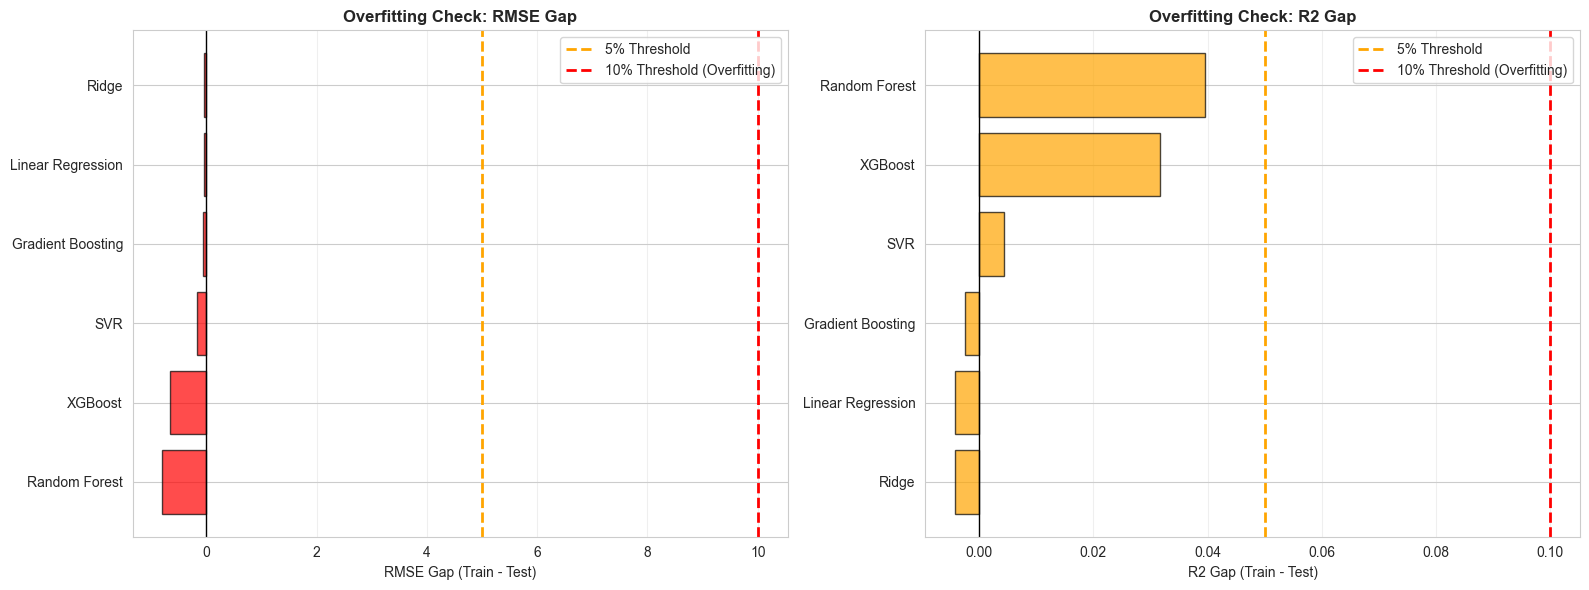


OVERFITTING ASSESSMENT

✓ Linear Regression - No significant overfitting detected
   Test R2: 0.6254
   RMSE Gap: -0.0477

✓ Ridge - No significant overfitting detected
   Test R2: 0.6254
   RMSE Gap: -0.0470

✓ Random Forest - No significant overfitting detected
   Test R2: 0.6842
   RMSE Gap: -0.8001

✓ XGBoost - No significant overfitting detected
   Test R2: 0.6807
   RMSE Gap: -0.6536

✓ Gradient Boosting - No significant overfitting detected
   Test R2: 0.6827
   RMSE Gap: -0.0615

✓ SVR - No significant overfitting detected
   Test R2: 0.6493
   RMSE Gap: -0.1796

✅ No significant overfitting detected in any model!


In [11]:
# Analyze overfitting by comparing training vs test performance
print("=" * 80)
print("OVERFITTING ANALYSIS")
print("=" * 80)

overfitting_analysis = pd.DataFrame({
    'Model': list(results.keys()),
    'Train RMSE': [results[m].get('Train RMSE', 0) for m in results.keys()],
    'Test RMSE': [results[m]['RMSE'] for m in results.keys()],
    'RMSE Gap': [results[m].get('RMSE Gap', 0) for m in results.keys()],
    'Train R2': [results[m].get('Train R2', 0) for m in results.keys()],
    'Test R2': [results[m]['R2'] for m in results.keys()],
    'R2 Gap': [results[m].get('R2 Gap', 0) for m in results.keys()]
})

print("\nTraining vs Test Performance Comparison:")
print(overfitting_analysis.round(4))

# Visualize overfitting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE gap
overfitting_analysis_sorted = overfitting_analysis.sort_values('RMSE Gap', ascending=False)
axes[0].barh(range(len(overfitting_analysis_sorted)), overfitting_analysis_sorted['RMSE Gap'].values,
             color='red', alpha=0.7, edgecolor='black')
axes[0].axvline(0, color='black', linestyle='-', linewidth=1)
axes[0].axvline(5, color='orange', linestyle='--', linewidth=2, label='5% Threshold')
axes[0].axvline(10, color='red', linestyle='--', linewidth=2, label='10% Threshold (Overfitting)')
axes[0].set_yticks(range(len(overfitting_analysis_sorted)))
axes[0].set_yticklabels(overfitting_analysis_sorted['Model'])
axes[0].set_xlabel('RMSE Gap (Train - Test)', fontsize=10)
axes[0].set_title('Overfitting Check: RMSE Gap', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# R2 gap
overfitting_analysis_sorted_r2 = overfitting_analysis.sort_values('R2 Gap', ascending=False)
axes[1].barh(range(len(overfitting_analysis_sorted_r2)), overfitting_analysis_sorted_r2['R2 Gap'].values,
             color='orange', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].axvline(0.05, color='orange', linestyle='--', linewidth=2, label='5% Threshold')
axes[1].axvline(0.10, color='red', linestyle='--', linewidth=2, label='10% Threshold (Overfitting)')
axes[1].set_yticks(range(len(overfitting_analysis_sorted_r2)))
axes[1].set_yticklabels(overfitting_analysis_sorted_r2['Model'])
axes[1].set_xlabel('R2 Gap (Train - Test)', fontsize=10)
axes[1].set_title('Overfitting Check: R2 Gap', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Identify overfitted models
print("\n" + "=" * 80)
print("OVERFITTING ASSESSMENT")
print("=" * 80)

overfitted_models = []
for idx, row in overfitting_analysis.iterrows():
    model_name = row['Model']
    rmse_gap = row['RMSE Gap']
    r2_gap = row['R2 Gap']
    test_r2 = row['Test R2']
    
    # Check for overfitting indicators
    is_overfitted = False
    reasons = []
    
    if rmse_gap < -10:  # Train RMSE much higher than test (unusual but possible)
        is_overfitted = True
        reasons.append(f"Large RMSE gap ({rmse_gap:.2f})")
    
    if r2_gap > 0.10:  # Train R2 much higher than test
        is_overfitted = True
        reasons.append(f"Large R2 gap ({r2_gap:.2%})")
    
    if test_r2 > 0.99:  # Near-perfect test score
        is_overfitted = True
        reasons.append("Near-perfect test R2 (≥99%)")
    
    if is_overfitted:
        overfitted_models.append(model_name)
        print(f"\n⚠️  {model_name} - POTENTIALLY OVERFITTED")
        print(f"   Test R2: {test_r2:.4f}")
        print(f"   RMSE Gap: {rmse_gap:.4f}")
        print(f"   R2 Gap: {r2_gap:.4f}")
        print(f"   Reasons: {', '.join(reasons)}")
    else:
        print(f"\n✓ {model_name} - No significant overfitting detected")
        print(f"   Test R2: {test_r2:.4f}")
        print(f"   RMSE Gap: {rmse_gap:.4f}")

if len(overfitted_models) > 0:
    print(f"\n🚨 WARNING: {len(overfitted_models)} model(s) show signs of overfitting!")
    print(f"   Overfitted models: {', '.join(overfitted_models)}")
    print(f"\n💡 Recommendations:")
    print(f"   - Increase regularization (reduce model complexity)")
    print(f"   - Add more training data if possible")
    print(f"   - Use simpler models or reduce hyperparameters")
else:
    print(f"\n✅ No significant overfitting detected in any model!")

## 8. Model Performance Comparison

Model Performance Comparison (sorted by RMSE):
                      RMSE     MAE      R2  Explained Variance    MAPE
Random Forest      10.8449  9.2684  0.6842              0.6842  0.1624
Gradient Boosting  10.8699  9.2801  0.6827              0.6827  0.1641
XGBoost            10.9033  9.2960  0.6807              0.6808  0.1644
SVR                11.4276  9.6363  0.6493              0.6493  0.1704
Ridge              11.8102  9.8854  0.6254              0.6255  0.1748
Linear Regression  11.8106  9.8845  0.6254              0.6254  0.1747


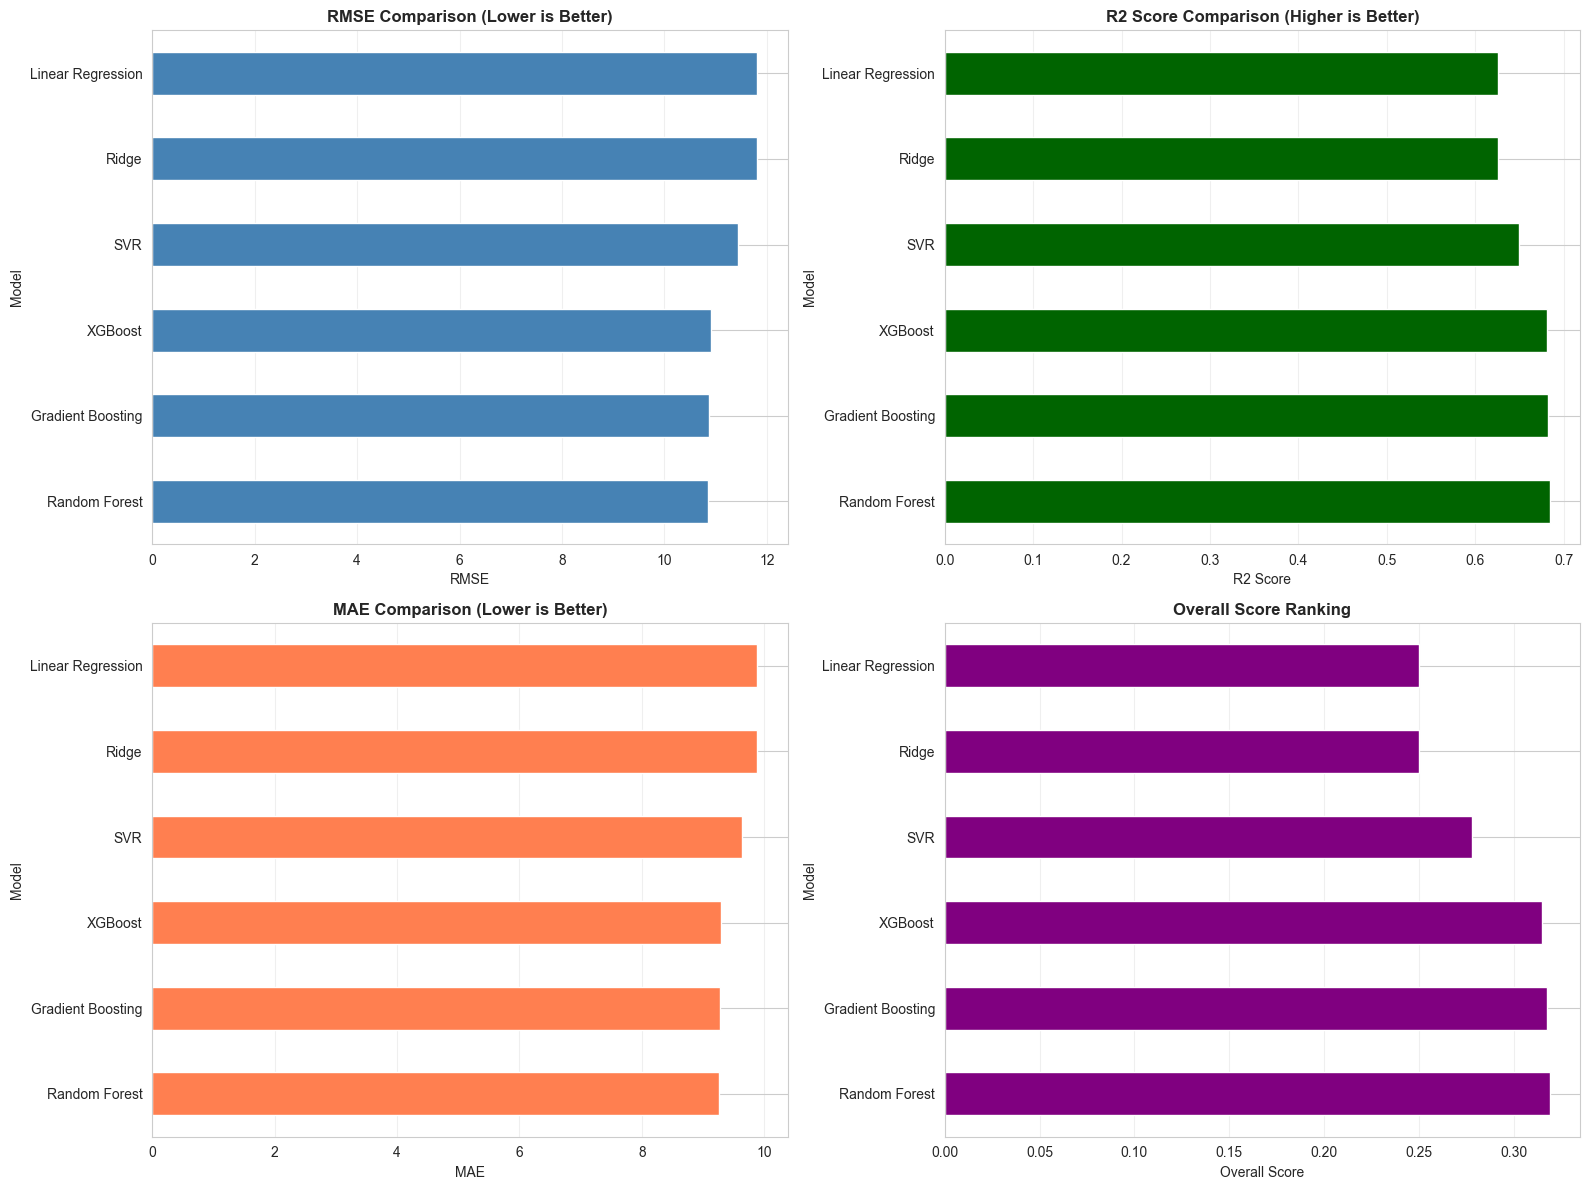


Overall Score Ranking:
                   Overall Score
Random Forest             0.3189
Gradient Boosting         0.3172
XGBoost                   0.3150
SVR                       0.2777
Ridge                     0.2502
Linear Regression         0.2502


In [12]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
comparison_metrics = ['RMSE', 'MAE', 'R2', 'Explained Variance', 'MAPE']
results_df = results_df[comparison_metrics].sort_values('RMSE', ascending=True)

print("Model Performance Comparison (sorted by RMSE):")
print("=" * 80)
print(results_df.round(4))
print("=" * 80)

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# RMSE comparison
results_df['RMSE'].plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('RMSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('RMSE', fontsize=10)
axes[0, 0].set_ylabel('Model', fontsize=10)
axes[0, 0].grid(True, alpha=0.3, axis='x')

# R2 comparison
results_df['R2'].plot(kind='barh', ax=axes[0, 1], color='darkgreen')
axes[0, 1].set_title('R2 Score Comparison (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('R2 Score', fontsize=10)
axes[0, 1].set_ylabel('Model', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='x')

# MAE comparison
results_df['MAE'].plot(kind='barh', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('MAE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('MAE', fontsize=10)
axes[1, 0].set_ylabel('Model', fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Overall ranking (based on normalized scores)
results_df['Overall Score'] = (
    (1 - results_df['RMSE'] / results_df['RMSE'].max()) * 0.4 +
    results_df['R2'] * 0.4 +
    (1 - results_df['MAE'] / results_df['MAE'].max()) * 0.2
)
results_df = results_df.sort_values('Overall Score', ascending=False)

results_df['Overall Score'].plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Overall Score Ranking', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Overall Score', fontsize=10)
axes[1, 1].set_ylabel('Model', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nOverall Score Ranking:")
print(results_df[['Overall Score']].round(4))

## 9. Prediction vs Actual Visualization

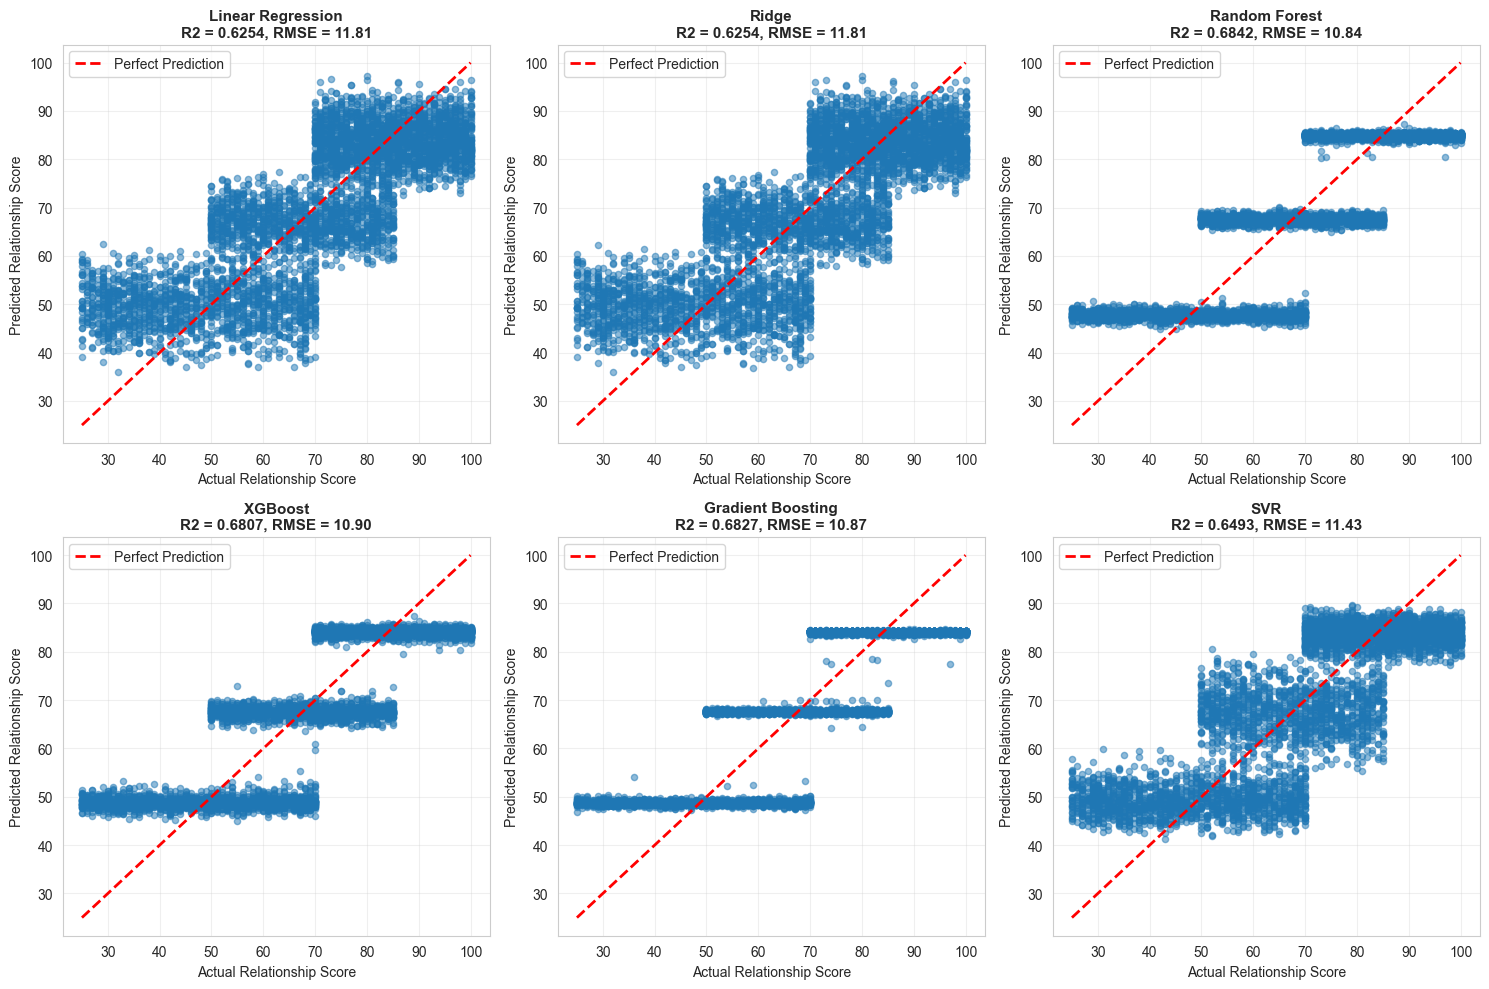

In [13]:
# Plot predicted vs actual for all models
n_models = len(results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.5, s=20)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Relationship Score', fontsize=10)
    ax.set_ylabel('Predicted Relationship Score', fontsize=10)
    ax.set_title(f'{name}\nR2 = {results[name]["R2"]:.4f}, RMSE = {results[name]["RMSE"]:.2f}', 
                 fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 10. Ensemble Models

In [14]:
# Create ensemble models using the trained base models
print("=" * 80)
print("TRAINING ENSEMBLE MODELS")
print("=" * 80)

# Use tree-based models for ensemble
base_models_for_ensemble = []
tree_model_names = ['Random Forest', 'XGBoost', 'Gradient Boosting']
for name in tree_model_names:
    if name in models:
        base_models_for_ensemble.append((name.lower().replace(' ', '_'), models[name]))

if len(base_models_for_ensemble) < 2:
    print("⚠️  Warning: Need at least 2 models for ensemble. Adding all available models...")
    for name, model in models.items():
        if name not in ['SVR']:  # Exclude SVR for ensemble
            base_models_for_ensemble.append((name.lower().replace(' ', '_'), model))

print(f"\nBase models for ensemble: {[name for name, _ in base_models_for_ensemble]}")

# Create Voting Regressor
print("\nTraining Voting Regressor...")
voting_reg = VotingRegressor(
    estimators=base_models_for_ensemble,
    n_jobs=-1
)
voting_reg.fit(X_train, y_train)

# Evaluate Voting Regressor
voting_pred = voting_reg.predict(X_test)
voting_mse = mean_squared_error(y_test, voting_pred)
voting_rmse = np.sqrt(voting_mse)
voting_mae = mean_absolute_error(y_test, voting_pred)
voting_r2 = r2_score(y_test, voting_pred)
voting_mape = mean_absolute_percentage_error(y_test, voting_pred)

results['Voting Regressor'] = {
    'MSE': voting_mse,
    'RMSE': voting_rmse,
    'MAE': voting_mae,
    'R2': voting_r2,
    'Explained Variance': explained_variance_score(y_test, voting_pred),
    'MAPE': voting_mape
}
predictions['Voting Regressor'] = voting_pred

print(f"  RMSE: {voting_rmse:.4f}")
print(f"  MAE: {voting_mae:.4f}")
print(f"  R2: {voting_r2:.4f}")
print(f"  MAPE: {voting_mape:.2%}")

# Create Stacking Regressor
print("\nTraining Stacking Regressor...")
stacking_reg = StackingRegressor(
    estimators=base_models_for_ensemble,
    final_estimator=Ridge(random_state=42),
    cv=5,
    n_jobs=-1
)
stacking_reg.fit(X_train, y_train)

# Evaluate Stacking Regressor
stacking_pred = stacking_reg.predict(X_test)
stacking_mse = mean_squared_error(y_test, stacking_pred)
stacking_rmse = np.sqrt(stacking_mse)
stacking_mae = mean_absolute_error(y_test, stacking_pred)
stacking_r2 = r2_score(y_test, stacking_pred)
stacking_mape = mean_absolute_percentage_error(y_test, stacking_pred)

results['Stacking Regressor'] = {
    'MSE': stacking_mse,
    'RMSE': stacking_rmse,
    'MAE': stacking_mae,
    'R2': stacking_r2,
    'Explained Variance': explained_variance_score(y_test, stacking_pred),
    'MAPE': stacking_mape
}
predictions['Stacking Regressor'] = stacking_pred

print(f"  RMSE: {stacking_rmse:.4f}")
print(f"  MAE: {stacking_mae:.4f}")
print(f"  R2: {stacking_r2:.4f}")
print(f"  MAPE: {stacking_mape:.2%}")

# Add ensemble models to models dictionary for saving
models['Voting Regressor'] = voting_reg
models['Stacking Regressor'] = stacking_reg

print("\n" + "=" * 80)
print("Ensemble models trained successfully!")
print("=" * 80)

TRAINING ENSEMBLE MODELS

Base models for ensemble: ['random_forest', 'xgboost', 'gradient_boosting']

Training Voting Regressor...
  RMSE: 10.8616
  MAE: 9.2757
  R2: 0.6832
  MAPE: 16.36%

Training Stacking Regressor...
  RMSE: 10.8294
  MAE: 9.2577
  R2: 0.6851
  MAPE: 16.23%

Ensemble models trained successfully!


## 11. Feature Importance Analysis

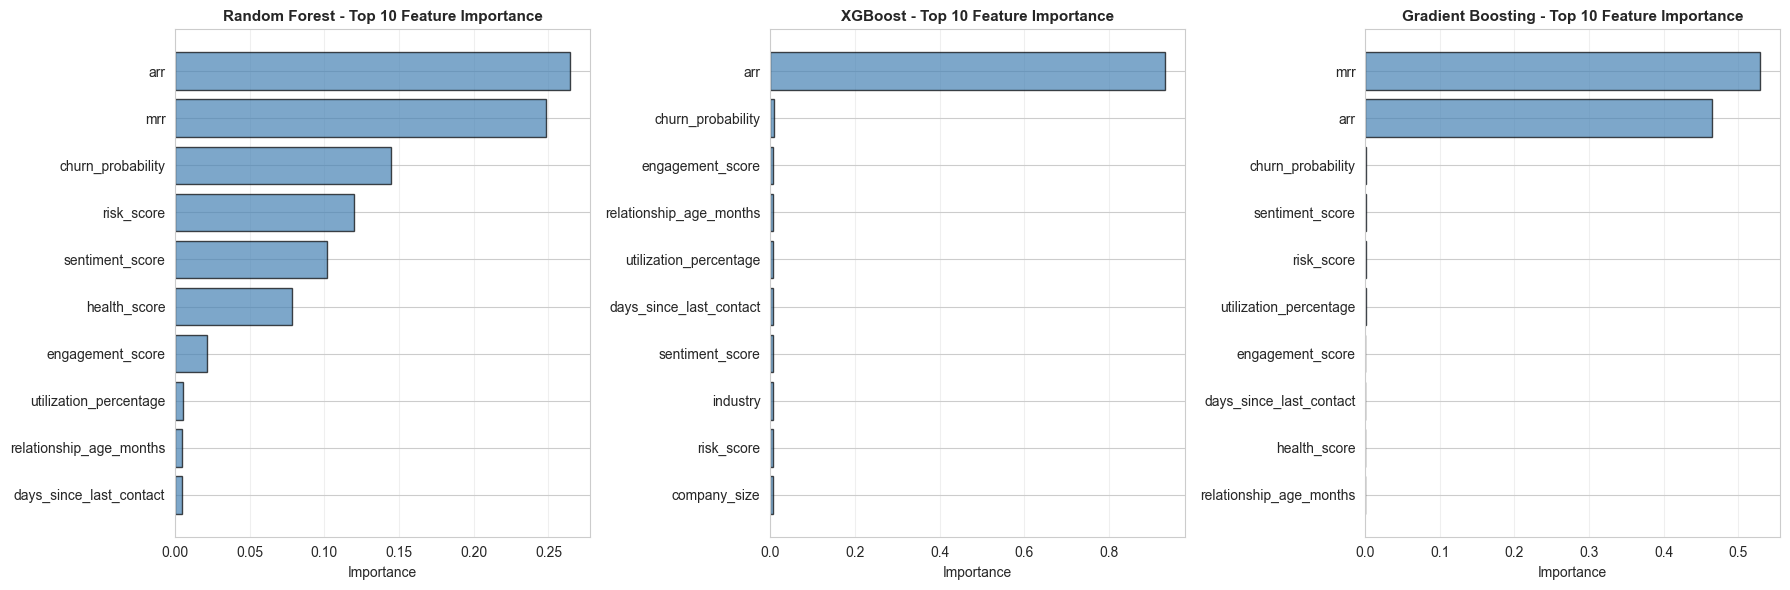

FEATURE IMPORTANCE ANALYSIS

Random Forest - Feature Importance:
------------------------------------------------------------
                 Feature  Importance
                     arr    0.264626
                     mrr    0.248508
       churn_probability    0.144558
              risk_score    0.119924
         sentiment_score    0.101931
            health_score    0.078475
        engagement_score    0.021354
  utilization_percentage    0.005517
 relationship_age_months    0.004802
 days_since_last_contact    0.004392
                industry    0.003692
            company_size    0.001718
   interaction_frequency    0.000503
contract_duration_months    0.000000


XGBoost - Feature Importance:
------------------------------------------------------------
                 Feature  Importance
                     arr    0.932237
       churn_probability    0.008774
        engagement_score    0.007815
 relationship_age_months    0.007100
  utilization_percentage    0.006847
 day

In [15]:
# Feature importance for tree-based models
tree_models = ['Random Forest', 'XGBoost', 'Gradient Boosting']
available_tree_models = [m for m in tree_models if m in models]

if available_tree_models:
    fig, axes = plt.subplots(1, len(available_tree_models), figsize=(6*len(available_tree_models), 6))
    if len(available_tree_models) == 1:
        axes = [axes]

    for idx, name in enumerate(available_tree_models):
        model = models[name]
        
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            feature_names = X.columns
            
            importance_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importances
            }).sort_values('importance', ascending=False)
            
            # Plot top 10 features
            top_features = importance_df.head(10)
            axes[idx].barh(range(len(top_features)), top_features['importance'], 
                          color='steelblue', edgecolor='black', alpha=0.7)
            axes[idx].set_yticks(range(len(top_features)))
            axes[idx].set_yticklabels(top_features['feature'])
            axes[idx].set_xlabel('Importance', fontsize=10)
            axes[idx].set_title(f'{name} - Top 10 Feature Importance', 
                               fontsize=11, fontweight='bold')
            axes[idx].grid(True, alpha=0.3, axis='x')
            axes[idx].invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Display feature importance tables
    print("=" * 80)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("=" * 80)
    for name in available_tree_models:
        model = models[name]
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            importance_df = pd.DataFrame({
                'Feature': X.columns,
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            
            print(f"\n{name} - Feature Importance:")
            print("-" * 60)
            print(importance_df.to_string(index=False))
            print()

## 12. Save All Models

In [16]:
# Create models directory
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Generate timestamp for file naming
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("=" * 80)
print("SAVING MODELS")
print("=" * 80)

# Save all individual models
saved_models = {}
for name, model in models.items():
    # Create safe filename
    safe_name = name.lower().replace(' ', '_')
    model_filename = models_dir / f"relationship_model_{safe_name}_{timestamp}.pkl"
    
    joblib.dump(model, model_filename)
    saved_models[name] = str(model_filename)
    print(f"✓ Saved {name}: {model_filename.name}")

# Save preprocessing objects
preprocessing_filename = models_dir / f"relationship_preprocessing_{timestamp}.pkl"
preprocessing_data = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_names': list(X.columns),
    'numerical_features': available_numerical,
    'categorical_features': available_categorical
}
joblib.dump(preprocessing_data, preprocessing_filename)
print(f"✓ Saved preprocessing objects: {preprocessing_filename.name}")

# Determine best model based on Overall Score
results_df_full = pd.DataFrame(results).T
if 'Overall Score' not in results_df_full.columns:
    results_df_full['Overall Score'] = (
        (1 - results_df_full['RMSE'] / results_df_full['RMSE'].max()) * 0.4 +
        results_df_full['R2'] * 0.4 +
        (1 - results_df_full['MAE'] / results_df_full['MAE'].max()) * 0.2
    )

best_model_name = results_df_full['Overall Score'].idxmax()
best_model = models[best_model_name]

# Save best model separately
best_model_filename = models_dir / f"relationship_model_best_{timestamp}.pkl"
joblib.dump(best_model, best_model_filename)
print(f"✓ Saved BEST MODEL ({best_model_name}): {best_model_filename.name}")

# Save model results
results_filename = models_dir / f"relationship_model_results_{timestamp}.csv"
results_df_full[['RMSE', 'MAE', 'R2', 'Explained Variance', 'MAPE', 'Overall Score']].to_csv(results_filename)
print(f"✓ Saved model results: {results_filename.name}")

# Save results as pickle for easy loading
results_pickle_filename = models_dir / f"relationship_model_results_{timestamp}.pkl"
with open(results_pickle_filename, 'wb') as f:
    import pickle
    pickle.dump({
        'results': results,
        'predictions': predictions,
        'best_model_name': best_model_name,
        'cv_results': cv_results if 'cv_results' in locals() else {},
        'timestamp': timestamp
    }, f)
print(f"✓ Saved detailed results: {results_pickle_filename.name}")

print("\n" + "=" * 80)
print("MODEL SAVING SUMMARY")
print("=" * 80)
print(f"Total models saved: {len(saved_models)}")
print(f"Best model: {best_model_name} (Overall Score: {results_df_full.loc[best_model_name, 'Overall Score']:.4f})")
print(f"Models directory: {models_dir.absolute()}")
print(f"Timestamp: {timestamp}")
print("\n" + "=" * 80)
print("Model Training and Saving Complete! 🎉")
print("=" * 80)

SAVING MODELS
✓ Saved Linear Regression: relationship_model_linear_regression_20260214_221417.pkl
✓ Saved Ridge: relationship_model_ridge_20260214_221417.pkl
✓ Saved Random Forest: relationship_model_random_forest_20260214_221417.pkl
✓ Saved XGBoost: relationship_model_xgboost_20260214_221417.pkl
✓ Saved Gradient Boosting: relationship_model_gradient_boosting_20260214_221417.pkl
✓ Saved SVR: relationship_model_svr_20260214_221417.pkl
✓ Saved Voting Regressor: relationship_model_voting_regressor_20260214_221417.pkl
✓ Saved Stacking Regressor: relationship_model_stacking_regressor_20260214_221417.pkl
✓ Saved preprocessing objects: relationship_preprocessing_20260214_221417.pkl
✓ Saved BEST MODEL (Stacking Regressor): relationship_model_best_20260214_221417.pkl
✓ Saved model results: relationship_model_results_20260214_221417.csv
✓ Saved detailed results: relationship_model_results_20260214_221417.pkl

MODEL SAVING SUMMARY
Total models saved: 8
Best model: Stacking Regressor (Overall Scor

In [17]:
# Final summary of all models
print("=" * 80)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 80)

final_results_df = pd.DataFrame(results).T
final_results_df = final_results_df[['RMSE', 'MAE', 'R2', 'Explained Variance', 'MAPE']].sort_values('RMSE', ascending=True)

print("\nAll Models Performance (sorted by RMSE):")
print(final_results_df.round(4))

print(f"\n{'='*80}")
print("BEST MODEL SELECTION")
print(f"{'='*80}")
print(f"Best Model: {best_model_name}")
print(f"  RMSE: {final_results_df.loc[best_model_name, 'RMSE']:.4f}")
print(f"  MAE: {final_results_df.loc[best_model_name, 'MAE']:.4f}")
print(f"  R2: {final_results_df.loc[best_model_name, 'R2']:.4f}")
print(f"  Explained Variance: {final_results_df.loc[best_model_name, 'Explained Variance']:.4f}")
print(f"  MAPE: {final_results_df.loc[best_model_name, 'MAPE']:.2%}")

print(f"\n{'='*80}")
print("MODEL TRAINING PIPELINE COMPLETE!")
print(f"{'='*80}")
print(f"✓ {len(models)} models trained")
print(f"✓ Hyperparameter tuning: {'Enabled' if ENABLE_TUNING else 'Disabled'}")
print(f"✓ Ensemble models: Voting Regressor, Stacking Regressor")
print(f"✓ All models saved to: {models_dir.absolute()}")
print(f"✓ Best model: {best_model_name}")
print(f"✓ Ready for production use!")
print(f"{'='*80}")

FINAL MODEL PERFORMANCE SUMMARY

All Models Performance (sorted by RMSE):
                       RMSE     MAE      R2  Explained Variance    MAPE
Stacking Regressor  10.8294  9.2577  0.6851              0.6851  0.1623
Random Forest       10.8449  9.2684  0.6842              0.6842  0.1624
Voting Regressor    10.8616  9.2757  0.6832              0.6832  0.1636
Gradient Boosting   10.8699  9.2801  0.6827              0.6827  0.1641
XGBoost             10.9033  9.2960  0.6807              0.6808  0.1644
SVR                 11.4276  9.6363  0.6493              0.6493  0.1704
Ridge               11.8102  9.8854  0.6254              0.6255  0.1748
Linear Regression   11.8106  9.8845  0.6254              0.6254  0.1747

BEST MODEL SELECTION
Best Model: Stacking Regressor
  RMSE: 10.8294
  MAE: 9.2577
  R2: 0.6851
  Explained Variance: 0.6851
  MAPE: 16.23%

MODEL TRAINING PIPELINE COMPLETE!
✓ 8 models trained
✓ Hyperparameter tuning: Enabled
✓ Ensemble models: Voting Regressor, Stacking Regre